In [3]:
# read csv all 3 csvs
import pandas as pd

countries = pd.read_csv('CountriesSD.csv').iloc[:,1:]
summer = pd.read_csv('SummerSD.csv').iloc[:,1:]
winter = pd.read_csv('WinterSD.csv').iloc[:,1:]

# Checking nan values
print(countries.isna().mean())
print(summer.isna().mean())
print(winter.isna().mean())

Country           0.000000
Code              0.000000
Population        0.024876
GDP per Capita    0.124378
dtype: float64
Year          0.000000
City          0.000000
Sport         0.000000
Discipline    0.000000
Athlete       0.000000
Code          0.000128
Gender        0.000000
Event         0.000000
Medal         0.000000
Country       0.174009
dtype: float64
Year          0.0
City          0.0
Sport         0.0
Discipline    0.0
Athlete       0.0
Country       0.0
Gender        0.0
Event         0.0
Medal         0.0
dtype: float64


Text(0.5, 1.0, 'Number of Unique Sports in Summer and Winter Olympics per Year')

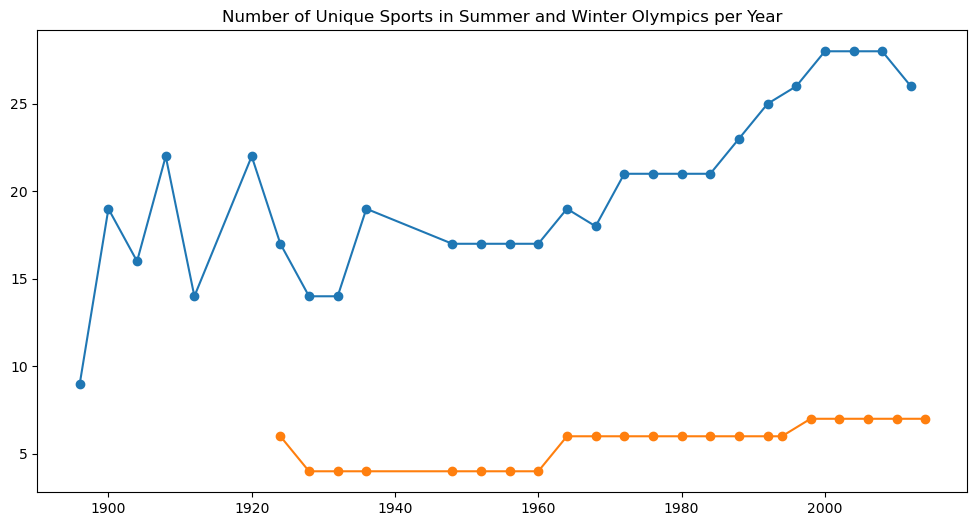

In [4]:
# Number of unique sports in summer and winter per year
summer_sports = summer.groupby('Year')['Sport'].nunique()
winter_sports = winter.groupby('Year')['Sport'].nunique()

# Plotting the number of unique sports in summer and winter per year
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(summer_sports.index, summer_sports.values, label='Summer Sports', marker='o')
plt.plot(winter_sports.index, winter_sports.values, label='Winter Sports', marker='o')
plt.title('Number of Unique Sports in Summer and Winter Olympics per Year')

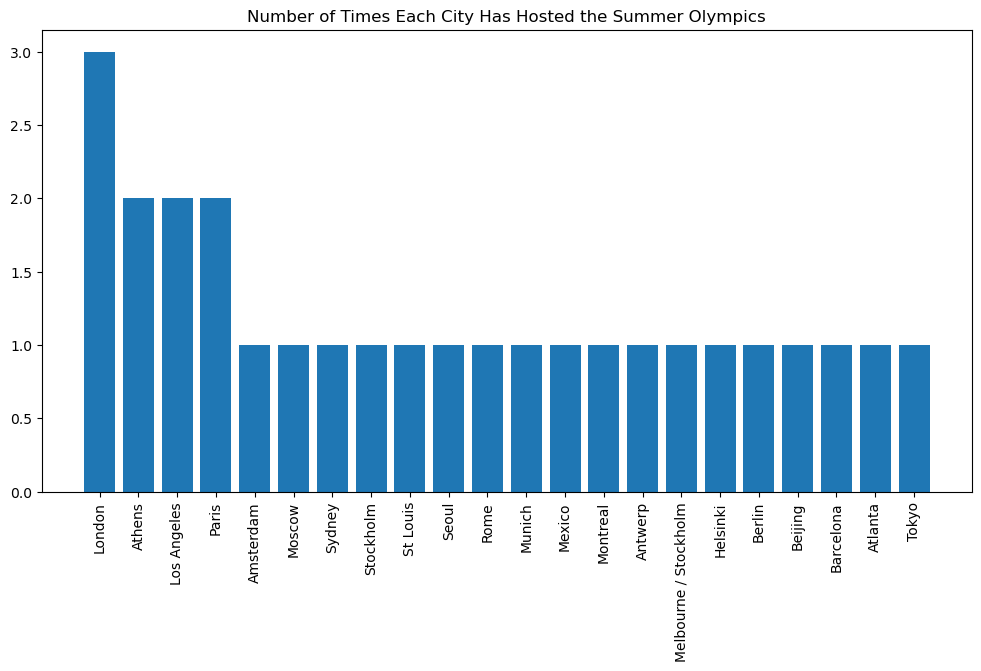

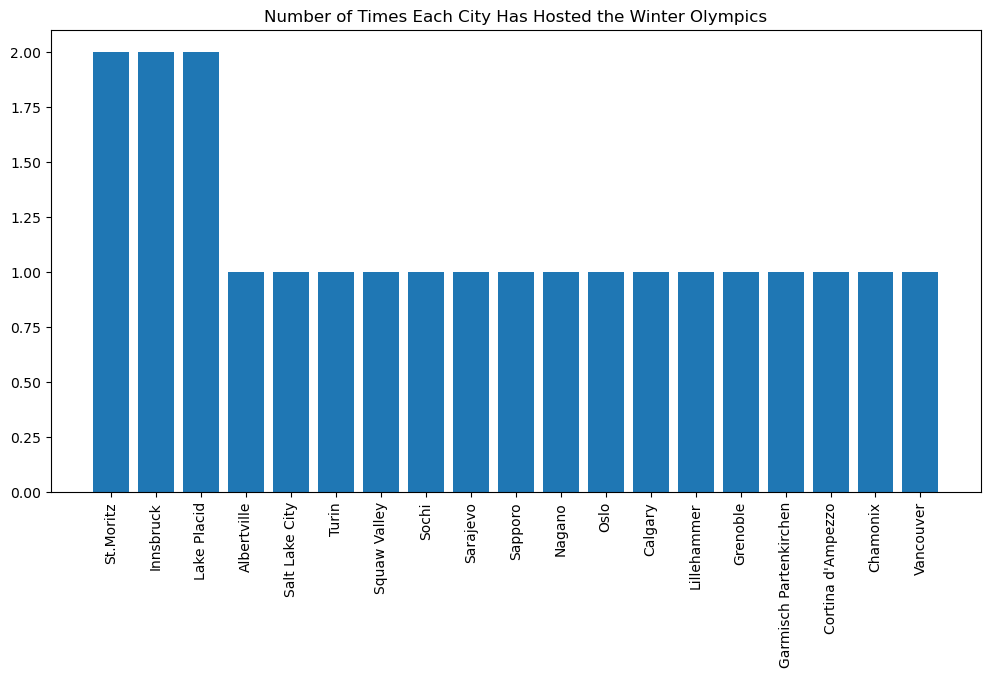

In [20]:
# plotting the number of times each city has hosted the Olympics
city_counts = summer.groupby('City')['Year'].nunique().reset_index(name='Count')
city_counts = city_counts.sort_values(by='Count', ascending=False)
plt.figure(figsize=(12, 6))
plt.bar(city_counts['City'], city_counts['Count'])
plt.title('Number of Times Each City Has Hosted the Summer Olympics')
plt.xticks(rotation=90)
plt.show()
# Same for winter
city_counts_winter = winter.groupby('City')['Year'].nunique().reset_index(name='Count')
city_counts_winter = city_counts_winter.sort_values(by='Count', ascending=False)
plt.figure(figsize=(12, 6))
plt.bar(city_counts_winter['City'], city_counts_winter['Count'])
plt.title('Number of Times Each City Has Hosted the Winter Olympics')
plt.xticks(rotation=90)
plt.show()

In [29]:
# Athletes with the most medals in summer and winter
summer_medals = summer.groupby('Athlete')['Medal'].count().reset_index(name='Medal Count')
summer_top_athletes = summer_medals.sort_values(by='Medal Count', ascending=False).head(10)
winter_medals = winter.groupby('Athlete')['Medal'].count().reset_index(name='Medal Count')
winter_top_athletes = winter_medals.sort_values(by='Medal Count', ascending=False).head(10)
print("Top 10 Athletes with the Most Medals in Summer Olympics:")
print(summer_top_athletes)
print("\nTop 10 Athletes with the Most Medals in Winter Olympics:") 
print(winter_top_athletes)

Top 10 Athletes with the Most Medals in Summer Olympics:
                   Athlete  Medal Count
14798       Michael Phelps           22
12602      Larisa Latynina           18
15781    Nikolay Andrianov           15
2665        Boris Shakhlin           13
5012   Edoardo Mangiarotti           13
19834          Takashi Ono           13
2532        Birgit Fischer           12
18675           Sawao Kato           12
15476     Natalie Coughlin           12
758           Alexei Nemov           12

Top 10 Athletes with the Most Medals in Winter Olympics:
                     Athlete  Medal Count
302   BJOERNDALEN, Ole Einar           13
591           DAEHLIE, Björn           12
239       BELMONDO, Stefania           10
3099        SMETANINA, Raisa           10
756          EGOROVA, Ljubov            9
1439        JERNBERG, Sixten            9
2532      PECHSTEIN, Claudia            9
666              DISL, Uschi            9
300          BJOERGEN, Marit            9
1085            GROSS, Ri

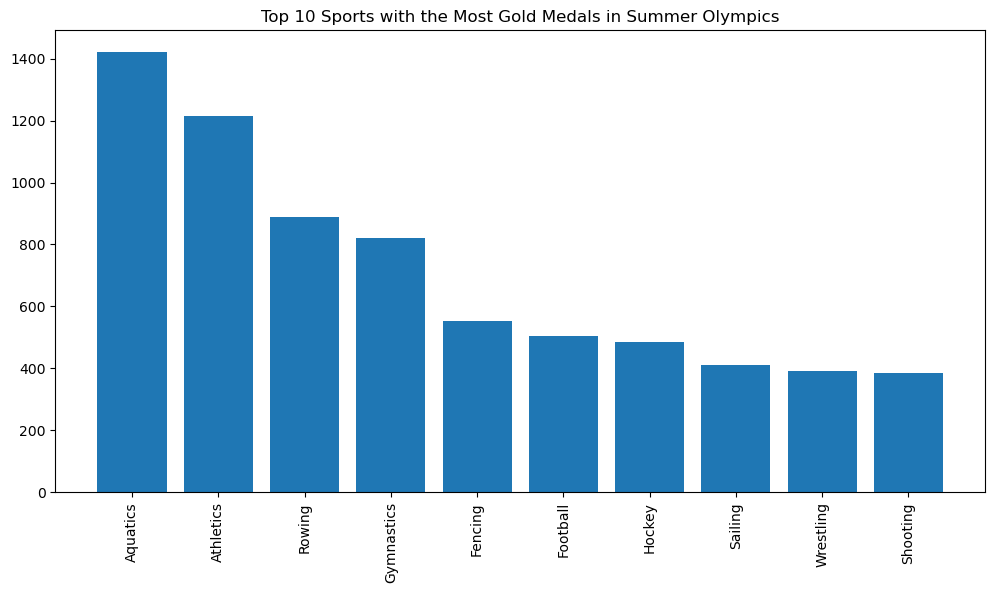

In [27]:
# Plot the number of gold medal per Sports(top 10 sports) in average per year in summer olympics
gold_medals = summer[summer['Medal'] == 'Gold'].groupby('Sport')['Medal'].count().reset_index(name='Count')
gold_medals = gold_medals.sort_values(by='Count', ascending=False).head(10)
plt.figure(figsize=(12, 6)) 
plt.bar(gold_medals['Sport'], gold_medals['Count'])
plt.title('Top 10 Sports with the Most Gold Medals in Summer Olympics')
plt.xticks(rotation=90)
plt.show()

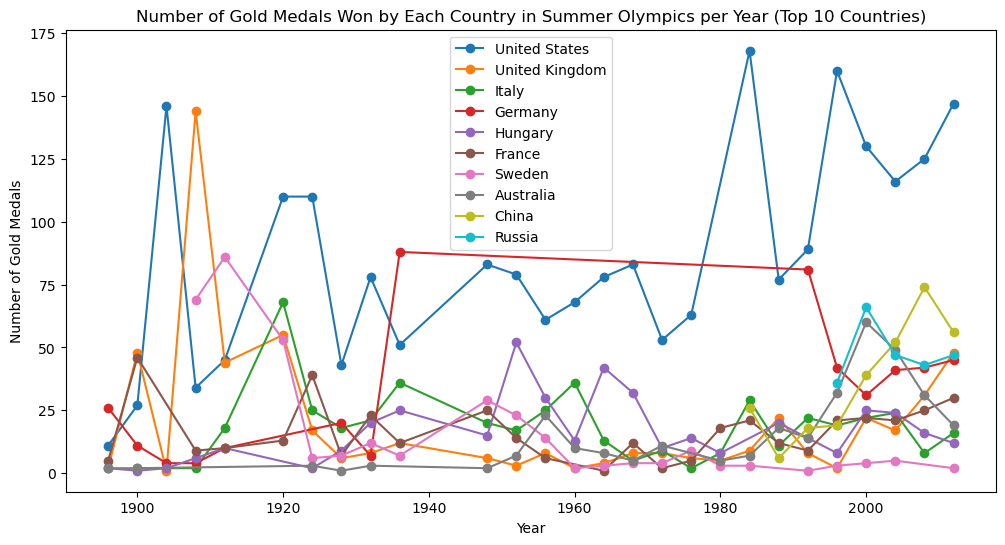

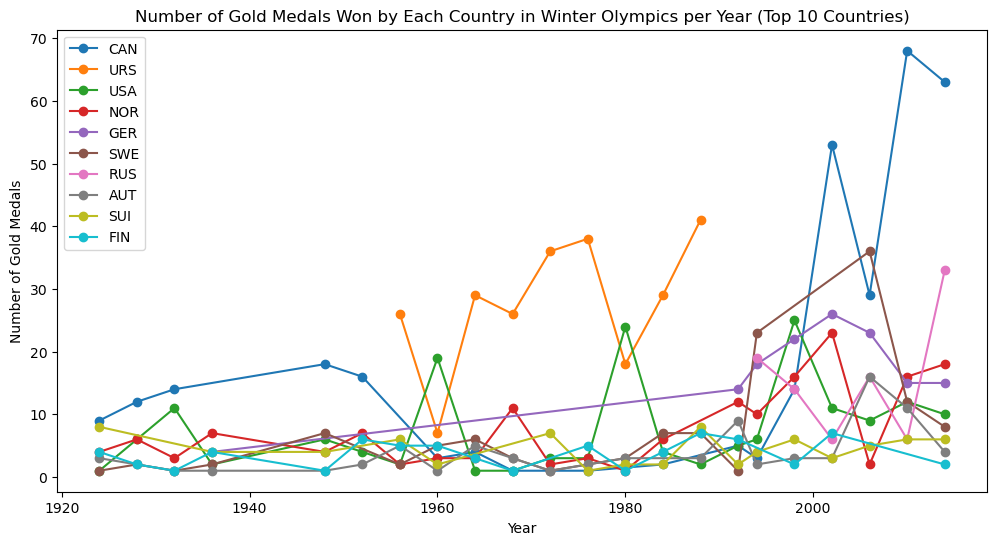

In [38]:
# Number of gold medals won by each country in summer and winter per year (top 10 countries)
# abcisse is the year, ordonnée is the number of gold medals, and each line represents a country
summer_gold = summer[summer['Medal'] == 'Gold'].groupby(['Year', 'Country'])['Medal'].count().reset_index(name='Count')
summer_top_countries = summer_gold.groupby('Country')['Count'].sum().reset_index(name='Total Gold Medals').sort_values(by='Total Gold Medals', ascending=False).head(10)
plt.figure(figsize=(12, 6)) 
for country in summer_top_countries['Country']:
    country_data = summer_gold[summer_gold['Country'] == country]
    plt.plot(country_data['Year'], country_data['Count'], label=country, marker='o')
plt.title('Number of Gold Medals Won by Each Country in Summer Olympics per Year (Top 10 Countries)')
plt.xlabel('Year')
plt.ylabel('Number of Gold Medals')
plt.legend()
# Same but with plotly :
import plotly.express as px
fig = px.line(summer_gold[summer_gold['Country'].isin(summer_top_countries['Country'])], x='Year', y='Count', color='Country', markers=True, title='Number of Gold Medals Won by Each Country in Summer Olympics per Year (Top 10 Countries)')
fig.show()
# Same for winter
winter_gold = winter[winter['Medal'] == 'Gold'].groupby(['Year', 'Country'])['Medal'].count().reset_index(name='Count')
winter_top_countries = winter_gold.groupby('Country')['Count'].sum().reset_index(name='Total Gold Medals').sort_values(by='Total Gold Medals', ascending=False).head(10)
plt.figure(figsize=(12, 6))
for country in winter_top_countries['Country']:
    country_data = winter_gold[winter_gold['Country'] == country]
    plt.plot(country_data['Year'], country_data['Count'], label=country, marker='o')
plt.title('Number of Gold Medals Won by Each Country in Winter Olympics per Year (Top 10 Countries)')
plt.xlabel('Year')
plt.ylabel('Number of Gold Medals')
plt.legend()
# Same but with plotly :
fig = px.line(winter_gold[winter_gold['Country'].isin(winter_top_countries['Country'])], x='Year', y='Count', color='Country', markers=True, title='Number of Gold Medals Won by Each Country in Winter Olympics per Year (Top 10 Countries)')
fig.show()

In [ ]:
# Concentration plot GDP per capita vs Population with plotly for the countries in the dataset
countries_gdp_population = countries[['Country', 'GDP per Capita', 'Population']]
fig = px.scatter(countries_gdp_population, x='GDP per Capita', y='Population', hover_data=['Country'], title='GDP per Capita vs Population of Countries in the Dataset')
fig.update_yaxes(type='log')
fig.show()